# Libraries

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import gzip
import pickle
import rich
import json
import graphviz
import os
import imageio
from PIL import Image
import pydot

from agentlab.analyze import inspect_results
from pathlib import Path

sns.set_context("notebook")  # makes the text in the plots larger, for better visibility
%config InlineBackend.figure_format = 'svg' # makes the plots HD in the notebook
mpl.rcParams["figure.autolayout"] = True  # enables tigh layout. Better multiplots
plt.rcParams["font.family"] = "sans-serif"

# Constants

In [49]:
TASK_NAME_PREFIX = "workarena.servicenow."
OFFSET = len(TASK_NAME_PREFIX)
TECHNIQUE = "hpa"
PKL_PREFIX = "step_"
PKL_SUFFIX = ".pkl.gz"
PKL_PATTERN = f"{PKL_PREFIX}*{PKL_SUFFIX}"
TASK_CATEGORIES = pd.read_csv("tasks_categories.csv")
BEST_TASKS = [
    "filter-hardware-list",
    "filter-service-catalog-item-list",
    "filter-user-list",
    "sort-user-list",
    "create-problem",
    "filter-change-request-list",
    "sort-service-catalog-item-list",
]

# data_paths = [
#     Path("/Users/montis/agentlab_results/genericagent-google-gemini-3-flash-preview-on-workarena-l1-baseline-30-steps"),
#     Path("/Users/montis/agentlab_results/2026-03-07_00-38-28_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-903"),
# ]
# LEADERBOARD_PATH = Path("/Users/montis/Documents/OneDrive - Ipazia SpA/Workarena Hackathon/browsergym_workarena_l1_official_leaderboard_2026-03-06.xlsx")
data_path = Path(
    "/Users/montis/agentlab_results/2026-03-07_00-38-28_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-903"
)
baseline_path = Path("/Users/montis/agentlab_results/genericagent-google-gemini-3-flash-preview-on-workarena-l1-baseline-30-steps")

In [4]:
def read_raw_data_and_reset_index(data_path: str) -> pd.DataFrame:
    df = inspect_results.load_result_df(data_path)
    df = df.reset_index()
    df["env.task_name"] = [task_name[OFFSET:] for task_name in df["env.task_name"]]
    return df


def add_tree_evolution_to_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    tree_evolution_list = []
    for _, row in df.iterrows():
        exp_dir = Path(row["exp_dir"])
        pkl_file_list = list(exp_dir.glob(PKL_PATTERN))
        pkl_file_list.sort(key=lambda x: int(Path(x.stem).stem.split("_")[-1]))
        tree_evolution = {}
        for index, pkl_file in enumerate(pkl_file_list):
            with gzip.open(pkl_file, "rb") as f:
                obj = pickle.load(f)
                if hasattr(obj.agent_info, "extra_info"):
                    tree_evolution[f"{PKL_PREFIX}{index}"] = obj.agent_info.extra_info["hpa_plan"]
        tree_evolution_list.append(tree_evolution)
    df["tree_evolution"] = tree_evolution_list
    return df


def read_and_process_data(data_path: str, save_csv: bool = False) -> pd.DataFrame:
    reindexed_df = read_raw_data_and_reset_index(data_path=data_path)
    processed_df = add_tree_evolution_to_dataframe(df=reindexed_df)
    if save_csv:
        processed_df.to_csv(f"{data_path.stem}_raw_data_with_tree_evolution.csv")
    return processed_df

In [5]:
baseline_df = read_raw_data_and_reset_index(data_path=baseline_path)

Loading results: 100%|██████████| 330/330 [00:00<00:00, 734.65it/s]


In [6]:
raw_df = read_and_process_data(data_path=data_path, save_csv=True)

Loading results: 100%|██████████| 330/330 [00:00<00:00, 614.34it/s]


In [7]:
# raw_df = pd.read_csv(f"{data_path.stem}_raw_data_with_tree_evolution.csv")
# test_obj = json.loads(raw_df.iloc[10]["tree_evolution"])
# rich.print(test_obj)

In [8]:
def get_global_layout(data):
    """
    Calculates a single global layout for all nodes present across all steps.
    """
    full_G = nx.DiGraph()
    for step in data.values():
        for node in step["tree_snapshot"]:
            full_G.add_node(node["id"])
            if node["parent_id"]:
                full_G.add_edge(node["parent_id"], node["id"])

    pydot_graph = nx.drawing.nx_pydot.to_pydot(full_G)
    pydot_graph.set_rankdir("LR")

    layout_dot = pydot_graph.create_dot(prog="dot").decode("utf-8")
    positioned_graphs = pydot.graph_from_dot_data(layout_dot)

    if not positioned_graphs:
        return {}, []

    positioned_graph = positioned_graphs[0]
    fixed_pos = {}
    all_node_ids = []

    for node in positioned_graph.get_nodes():
        name = node.get_name().strip('"')
        if name in ("graph", "node", "edge"):
            continue
        pos = node.get_pos()
        if pos:
            clean_pos = pos.replace('"', "")
            fixed_pos[name] = f"{clean_pos}!"
            all_node_ids.append(name)

    return fixed_pos, all_node_ids


def create_fixed_graphviz_step(snapshot, fixed_layout, all_node_ids, title="Tree Step"):
    """
    Renders a snapshot with a modern blue theme and rounded rectangles.
    """
    # CSS-inspired Blue Palette
    type_colors = {
        "OR": "#EBF5FB",  # Extra Light Blue
        "AND": "#AED6F1",  # Light Blue
        "ACTION": "#5DADE2",  # Professional Blue
        "UNKNOWN": "#F4F6F7",  # Ghost White
    }

    status_border_colors = {
        "SUCCESS": "#1B4F72",  # Dark Navy
        "VISITED": "#2E86C1",  # Ocean Blue
        "UNVISITED": "#D6DBDF",  # Silver Blue
    }

    dot = graphviz.Digraph(engine="neato", format="png")
    dot.attr(overlap="false", splines="true", bgcolor="white", pad="0.5")
    dot.attr(
        label=f"\n\n{title}\n",
        labelloc="t",
        fontsize="24",
        fontname="Helvetica-Bold",
        fontcolor="#1B4F72",
    )

    current_nodes = {str(n["id"]): n for n in snapshot}
    current_edges = {(str(n["parent_id"]), str(n["id"])) for n in snapshot if n["parent_id"]}

    for nid in all_node_ids:
        pos = fixed_layout.get(nid)
        if not pos:
            continue

        if nid in current_nodes:
            node_data = current_nodes[nid]
            ntype = node_data["type"]
            status = node_data["status"]

            # Label with ID in small font and Type in Bold
            label = f"""<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="2">
                           <TR><TD><FONT POINT-SIZE="9" COLOR="#2E86C1">{nid}</FONT></TD></TR>
                           <TR><TD><B><FONT POINT-SIZE="12" COLOR="#1B4F72">{ntype}</FONT></B></TD></TR>
                        </TABLE>>"""

            # Forcing "rect" and "rounded" for every node
            dot.node(
                nid,
                label=label,
                pos=pos,
                style="filled, rounded",
                fillcolor=type_colors.get(ntype, "#FFFFFF"),
                color=status_border_colors.get(status, "#BDC3C7"),
                penwidth="4" if status == "SUCCESS" else "1.5",
                shape="rect",
                fontname="Helvetica",
            )
        else:
            # Invisible placeholder
            dot.node(nid, label="", pos=pos, style="invis", width="1.0", height="0.6")

    # Draw Edges with a subtle blue-grey color
    for parent, child in current_edges:
        dot.edge(parent, child, color="#AED6F1", penwidth="2", arrowhead="vee")

    return dot


def generate_tree_animation(data, filename="blue_tree_evolution.gif", fps=1):
    temp_folder = "temp_frames"
    if not os.path.exists(temp_folder):
        os.makedirs(temp_folder)

    fixed_layout, all_node_ids = get_global_layout(data)
    images = []
    steps = sorted(data.keys(), key=lambda x: int(x.split("_")[1]))

    print(f"Generating frames for {len(steps)} steps...")

    for i, step_name in enumerate(steps):
        snapshot = data[step_name]["tree_snapshot"]
        gv_graph = create_fixed_graphviz_step(
            snapshot, fixed_layout, all_node_ids, title=f"Exploration: {step_name}"
        )

        frame_base = os.path.join(temp_folder, f"frame_{i:03d}")
        gv_graph.render(frame_base, cleanup=True)

        img = Image.open(f"{frame_base}.png").convert("RGB")
        images.append(np.array(img))

    # Standardize sizes to prevent imageio errors
    max_h = max(im.shape[0] for im in images)
    max_w = max(im.shape[1] for im in images)

    final_frames = []
    for im in images:
        if im.shape[0] != max_h or im.shape[1] != max_w:
            new_im = Image.new("RGB", (max_w, max_h), (255, 255, 255))
            new_im.paste(Image.fromarray(im), (0, 0))
            final_frames.append(np.array(new_im))
        else:
            final_frames.append(im)

    imageio.mimsave(filename, final_frames, fps=fps, loop=0)
    print(f"Done! Animation saved as: {filename}")

    # Cleanup
    for f in os.listdir(temp_folder):
        os.remove(os.path.join(temp_folder, f))
    os.rmdir(temp_folder)

In [ ]:
generate_tree_animation(raw_df.iloc[33]["tree_evolution"], filename="my_search_tree.gif", fps=1)

Generating frames for 13 steps...


Done! Animation saved as: my_search_tree.gif


In [9]:
def visualize_retried_tasks(df: pd.DataFrame, max_depth: int = 4) -> None:
    # Select only the rows of the dataframe where the tree_counts.max_depth_reached is 4
    mask = [
        any(step["tree_counts"]["max_depth_reached"] == max_depth for step in row_val.values())
        for row_val in df["tree_evolution"]
    ]
    retried_tasks_df = df[mask].copy()
    # Sort task names in ascending order by the median of the cumulative rewards
    task_rank = (
        retried_tasks_df.groupby("env.task_name")["cum_reward"]
        .sum()
        .sort_values(ascending=True)
        .index
    )
    retried_tasks_df["env.task_name"] = pd.Categorical(
        retried_tasks_df["env.task_name"], categories=task_rank, ordered=True
    )
    # Plot the histogram
    plt.figure(figsize=(10, 6))
    g = sns.histplot(
        data=retried_tasks_df,
        y="env.task_name",
        hue="cum_reward",
        multiple="stack",
        discrete=True,
        shrink=0.8,
    )

    g.set_xlabel("Tasks Count")
    g.set_ylabel("Task Name")
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    g.grid(axis="x", linestyle="--", alpha=0.5, linewidth=0.8)
    plt.show()


def visualize_pruned_tasks(df: pd.DataFrame, median_threshold: int = 0) -> None:
    # Create a copy of the dataframe to avoid modifying the original one
    df_copy = df.copy()
    # Create a new column with the total number of pruned nodes for each row in the dataframe
    total_pruned_list = [
        sum(len(step["tree_update"]["prune"]) for step in row_val.values())
        for row_val in df_copy["tree_evolution"]
    ]
    df_copy["total_pruned"] = total_pruned_list
    # Filter the dataframe to only include tasks with a median number of pruned nodes greater than the threshold. Median is used for robustness against outliers.
    pruned_tasks_df = df_copy[
        df_copy.groupby("env.task_name")["total_pruned"].transform("median") > median_threshold
    ].copy()
    # Sort the tasks by the median number of pruned nodes in ascending order
    task_rank = (
        pruned_tasks_df.groupby("env.task_name")["total_pruned"]
        .median()
        .sort_values(ascending=True)
        .index
    )
    pruned_tasks_df["env.task_name"] = pd.Categorical(
        pruned_tasks_df["env.task_name"], categories=task_rank, ordered=True
    )
    # Plot the bar plot
    plt.figure(figsize=(8, 5))
    g = sns.barplot(
        pruned_tasks_df,
        y="env.task_name",
        x="total_pruned",
        estimator="median",
        err_kws={"linewidth": 0.8},
    )
    g.set_xlabel("Median Pruned Nodes")
    g.set_ylabel("Task Name")
    g.grid(axis="x", linestyle="--", alpha=0.5, linewidth=0.8)
    plt.show()

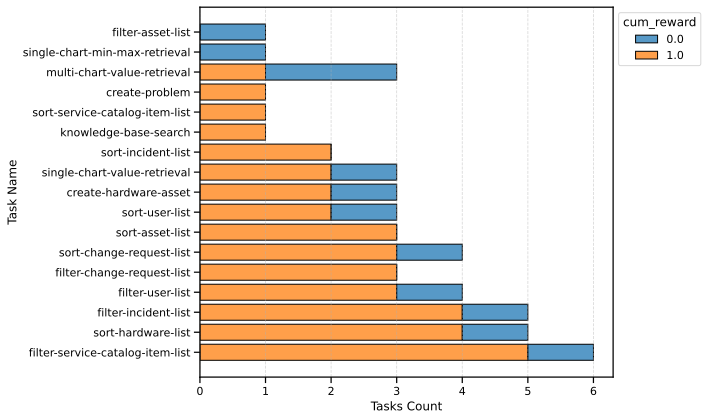

In [10]:
visualize_retried_tasks(raw_df)

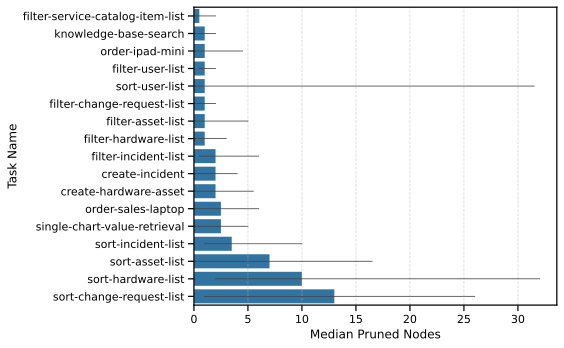

In [11]:
visualize_pruned_tasks(raw_df)

In [29]:
def compute_pruned_nodes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute the total number of pruned nodes for each row in the dataframe
    """
    df["pruned_nodes"] = df["tree_evolution"].apply(
        lambda x: sum(len(step["tree_update"]["prune"]) for step in x.values())
    )
    return df

def aggregate_statistics_by_task_name(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute the statistics grouping by task name
    """
    return df.groupby("env.task_name", observed=False).agg(
        cum_reward=("cum_reward", "mean"),
        n_steps=("n_steps", "mean"),
        median_pruned=("pruned_nodes", "median")
    )

def compute_aggregated_relative_statistics(df: pd.DataFrame, baseline_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute the statistics relative to the baseline and aggregated by task name
    """
    baseline_stats = baseline_df.groupby("env.task_name").agg(cum_reward=("cum_reward", "mean"), n_steps=("n_steps", "mean"))
    df["relative_cum_reward"] = (df["cum_reward"] - baseline_stats["cum_reward"]) / baseline_stats["cum_reward"] * 100
    df["relative_n_steps"] = (df["n_steps"] - baseline_stats["n_steps"]) / baseline_stats["n_steps"] * 100
    return df

def filter_and_sort_by_median_pruned(df: pd.DataFrame, median_threshold: int = 0) -> pd.DataFrame:
    """
    Filter and sort the dataframe by the median number of pruned nodes using a threshold
    """
    filtered_df = df[df["median_pruned"] > median_threshold]
    return filtered_df.sort_values("median_pruned")

def vectorize_task_category(df: pd.DataFrame) -> pd.DataFrame:
    """
    Vectorize the task category
    """
    task_lookup = dict(zip(TASK_CATEGORIES["task_name"], TASK_CATEGORIES["category"]))
    df["task_category"] = df.index.map(lambda x: task_lookup.get(x, "Unknown"))
    return df

def process_for_pruned_nodes_visualization(df: pd.DataFrame, baseline_df: pd.DataFrame | None = None, median_threshold: int = 0) -> pd.DataFrame:
    """
    Process the dataframe for the visualization of pruned nodes against cumulative reward or number of steps
    """
    df = compute_pruned_nodes(df)
    df = aggregate_statistics_by_task_name(df)
    if baseline_df is not None:
        df = compute_aggregated_relative_statistics(df, baseline_df)
    df = filter_and_sort_by_median_pruned(df, median_threshold)
    df = vectorize_task_category(df)
    return df

In [ ]:
def visualize_pruned_tasks_vs_cum_reward(df: pd.DataFrame, median_threshold: int = 0):
    aggregated_df = process_for_pruned_nodes_visualization(df, median_threshold)

    # Visualization
    plt.figure(figsize=(8, 5))
    g = sns.scatterplot(
        data=aggregated_df,
        x="cum_reward",
        y="median_pruned",
        hue="task_category",
    )
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1), title="Task Category")
    g.set_xlabel("Average Reward")
    g.set_ylabel("Median Pruned Nodes")
    g.grid(axis="both", linestyle="--", alpha=0.5, linewidth=0.8)
    plt.show()

def visualize_pruned_tasks_vs_n_steps(df: pd.DataFrame, median_threshold: int = 0) -> None:
    aggregated_df = process_for_pruned_nodes_visualization(df, median_threshold)

    # Visualization
    plt.figure(figsize=(8, 5))
    g = sns.scatterplot(
        data=aggregated_df,
        x="n_steps",
        y="median_pruned",
        hue="task_category",
    )
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1), title="Task Category")
    g.set_xlabel("Average Number of Steps")
    g.set_ylabel("Median Pruned Nodes")
    g.grid(axis="both", linestyle="--", alpha=0.5, linewidth=0.8)
    plt.show()

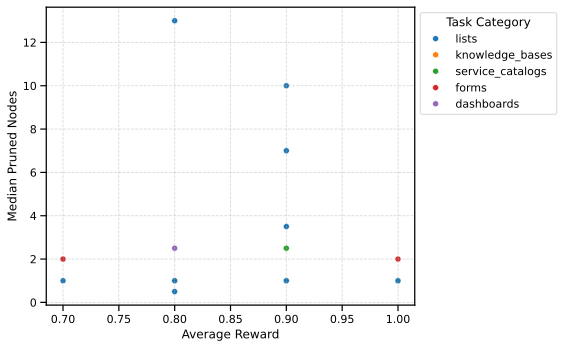

In [27]:
visualize_pruned_tasks_vs_cum_reward(raw_df)

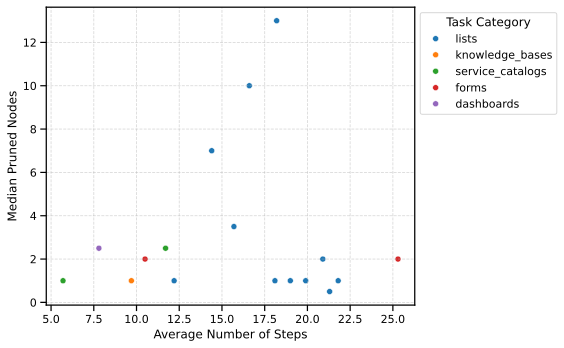

In [28]:
visualize_pruned_tasks_vs_n_steps(raw_df)

In [ ]:
def visualize_pruned_tasks_vs_relative_cum_reward(baseline_df: pd.DataFrame, df: pd.DataFrame, median_threshold: int = 0):
    aggregated_df = process_for_pruned_nodes_visualization(df, baseline_df, median_threshold)

    # Visualization
    plt.figure(figsize=(8, 5))
    g = sns.scatterplot(
        data=aggregated_df,
        x="relative_cum_reward",
        y="median_pruned",
        hue="task_category",
    )
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1), title="Task Category")
    g.set_xlabel("Relative Average Reward (higher is better)")
    g.set_ylabel("Median Pruned Nodes")
    g.xaxis.set_major_locator(ticker.MultipleLocator(10))
    g.xaxis.set_major_formatter(ticker.PercentFormatter(symbol='%', is_latex=False))
    g.grid(axis="both", linestyle="--", alpha=0.5, linewidth=0.8)
    plt.show()

def visualize_pruned_tasks_vs_relative_n_steps(baseline_df: pd.DataFrame, df: pd.DataFrame, median_threshold: int = 0):
    aggregated_df = process_for_pruned_nodes_visualization(df, baseline_df, median_threshold)

    # Visualization
    plt.figure(figsize=(8, 5))
    g = sns.scatterplot(
        data=aggregated_df,
        x="relative_n_steps",
        y="median_pruned",
        hue="task_category",
    )
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1), title="Task Category")
    g.set_xlabel("Relative Average Number of Steps (lower is better)")
    g.set_ylabel("Median Pruned Nodes")
    g.xaxis.set_major_locator(ticker.MultipleLocator(10))
    g.xaxis.set_major_formatter(ticker.PercentFormatter(symbol='%', is_latex=False))
    g.grid(axis="both", linestyle="--", alpha=0.5, linewidth=0.8)
    plt.show()

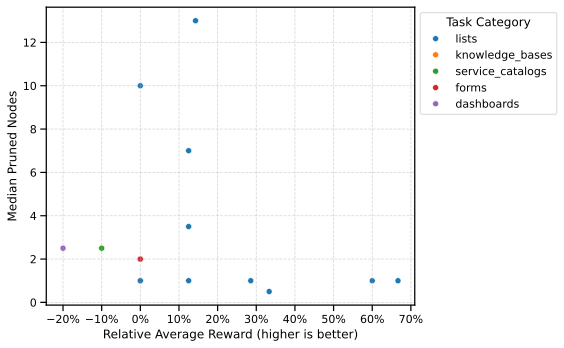

In [31]:
visualize_pruned_tasks_vs_relative_cum_reward(baseline_df, raw_df)

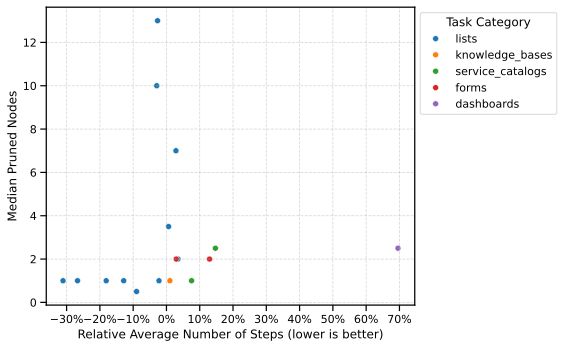

In [32]:
visualize_pruned_tasks_vs_relative_n_steps(baseline_df, raw_df)

In [33]:
def count_retries(tree_evolution: dict) -> int:
    n_retries = 0
    last_depth_4 = 0
    # .values() gives us the steps; we just iterate and track the state
    for step in tree_evolution.values():
        current_depth_4 = step["tree_counts"]["by_depth"].get("4", 0)
        if current_depth_4 > last_depth_4:
            n_retries += 1
            last_depth_4 = current_depth_4
    return n_retries

def compute_task_retries(df: pd.DataFrame) -> pd.DataFrame:
    df["task_retries"] = df["tree_evolution"].apply(count_retries)
    return df

In [34]:
processed_df = compute_task_retries(raw_df)
processed_df = compute_pruned_nodes(processed_df)

In [41]:
aggregated_processed_df = processed_df.groupby("env.task_name").agg(
    avg_task_retries=("task_retries", "mean"),
    median_pruned=("pruned_nodes", "median"),
    avg_cum_reward=("cum_reward", "mean"),
    avg_n_steps=("n_steps", "mean")
)

In [50]:
aggregated_processed_df = vectorize_task_category(aggregated_processed_df)

In [51]:
aggregated_processed_df

,avg_task_retries,median_pruned,avg_cum_reward,avg_n_steps,task_category
env.task_name,,,,,
all-menu,0.0,0.0,1.0,3.2,menus
create-change-request,0.0,0.0,1.0,9.6,forms
create-hardware-asset,0.3,2.0,0.7,25.3,forms
create-incident,0.0,2.0,1.0,10.5,forms
create-problem,0.1,0.0,1.0,6.3,forms
create-user,0.0,0.0,0.9,11.2,forms
filter-asset-list,0.2,1.0,0.7,21.8,lists
filter-change-request-list,0.3,1.0,1.0,18.1,lists
filter-hardware-list,0.0,1.0,0.8,19.9,lists


In [53]:
class WorkArenaVisualizer:
    def __init__(self, df):
        self.df = df
        # Extract task category from the name (e.g., 'sort', 'create', 'filter')
        # self.df['category'] = self.df['env.task_name'].apply(lambda x: x.split('-')[0])
        sns.set_theme(style="whitegrid")

    def plot_efficiency_frontier(self):
        """Plot relationship between task length and pruning efficiency."""
        plt.figure(figsize=(10, 6))
        scatter = sns.scatterplot(
            data=self.df, 
            x='avg_n_steps', 
            y='median_pruned', 
            hue='task_category', 
            size='avg_cum_reward',
            sizes=(20, 200),
            palette='viridis'
        )
        plt.title('Pruning Efficiency: Do longer tasks require more pruning?', fontsize=14)
        plt.xlabel('Average Number of Steps')
        plt.ylabel('Median Nodes Pruned')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    def plot_category_performance(self):
        """Compare success rate and steps across task types."""
        fig, ax1 = plt.subplots(figsize=(12, 6))

        # Bar plot for steps
        sns.barplot(data=self.df, x='task_category', y='avg_n_steps', ax=ax1, alpha=0.6, color='skyblue', capsize=.1)
        ax1.set_ylabel('Avg Steps (Bar)', color='blue')
        ax1.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)

        # Line plot for reward on secondary axis
        ax2 = ax1.twinx()
        sns.pointplot(data=self.df, x='task_category', y='avg_cum_reward', ax=ax2, color='red', markers='D')
        ax2.set_ylabel('Avg Reward (Line)', color='red')
        ax2.set_ylim(0, 1.1)
        ax2.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)

        plt.title('Performance by Task Category: Complexity vs. Success', fontsize=14)
        plt.tight_layout()
        plt.show()

    def plot_retry_impact(self):
        """Analyze if retries lead to success."""
        plt.figure(figsize=(10, 6))
        # Adding a bit of jitter to X to see overlapping points better
        sns.regplot(data=self.df, x='avg_task_retries', y='avg_cum_reward', 
                    scatter_kws={'s': self.df['avg_n_steps']*10, 'alpha':0.5},
                    line_kws={'color':'red', 'linestyle':'--'})
        
        plt.title('Impact of Retry Mechanism on Final Reward', fontsize=14)
        plt.xlabel('Avg Task Retries')
        plt.ylabel('Avg Cumulative Reward')
        plt.show()

    def plot_correlation(self):
        """Heatmap of metric correlations."""
        plt.figure(figsize=(8, 6))
        cols = ['avg_task_retries', 'median_pruned', 'avg_cum_reward', 'avg_n_steps']
        corr = self.df[cols].corr()
        sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
        plt.title('Correlation between Tree Metrics and Success')
        plt.show()

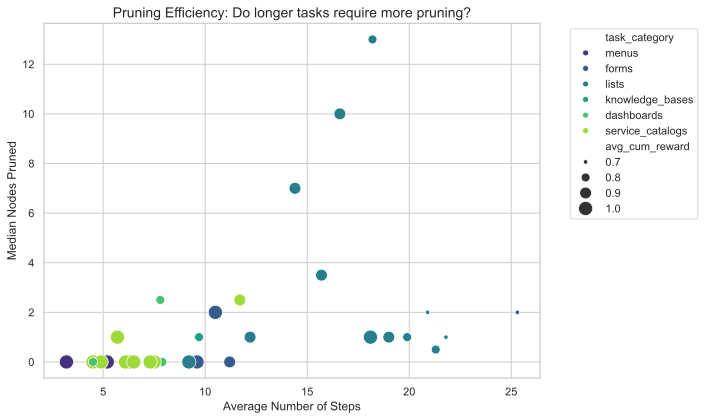

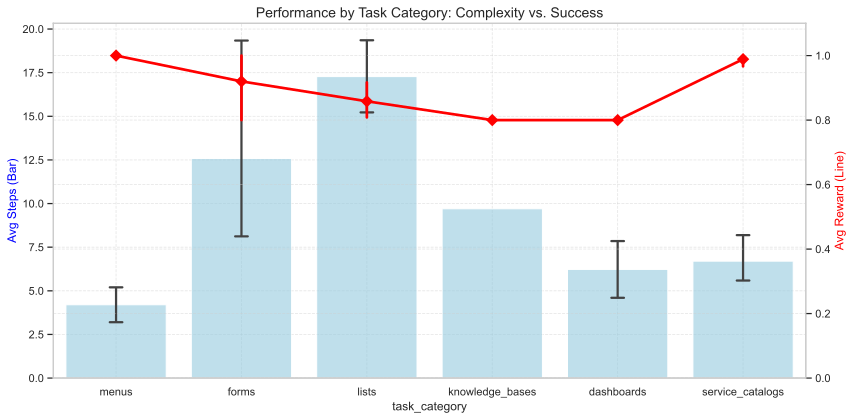

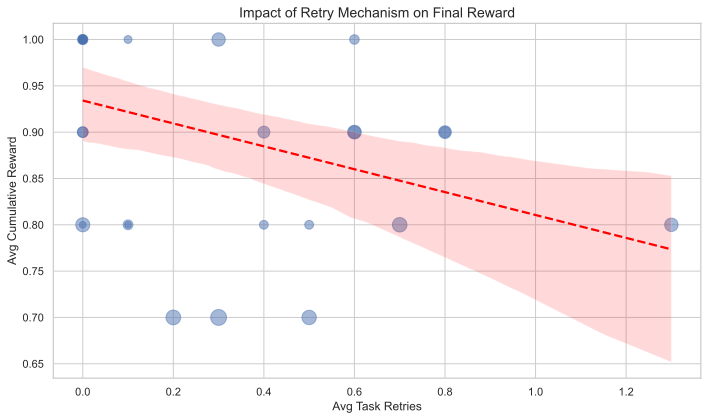

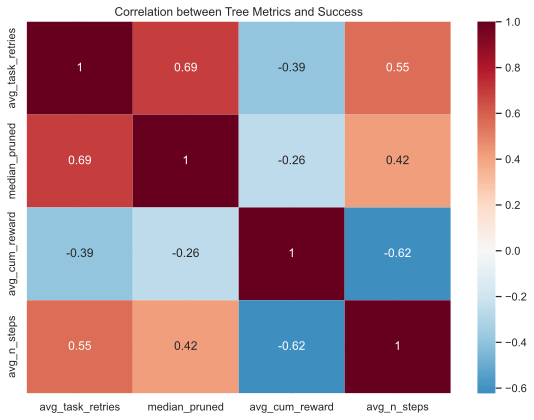

In [54]:
# 2. Initialize and Plot
viz = WorkArenaVisualizer(aggregated_processed_df)
viz.plot_efficiency_frontier()
viz.plot_category_performance()
viz.plot_retry_impact()
viz.plot_correlation()

In [89]:
# rich.print(raw_df.iloc[33]["tree_evolution"])

In [88]:
# rich.print(raw_df.iloc[10]["tree_evolution"]["step_5"]["tree_snapshot"])

In [ ]:
# for idx, step in raw_df.iloc[10]["tree_evolution"].items():
#     print(step["tree_update"])

{'prune': [], 'update': {}, 'n_pruned': 0, 'n_updated': 0}
{'prune': [], 'update': {'0.2': "Enter 'Scheduled maintenance on database server - bond_trading_uk' into the 'Short description' field", '0.3': "Enter 'toxicarol diadem filterable quinoline Ostertagia' into the 'Description' field", '0.4': "Enter 'bond_trade_aus' into the 'Configuration item' field", '0.5': "Fill the 'Justification', 'Implementation plan', 'Backout plan', and 'Test plan' fields within the 'Planning' tab section", '0.6': "Switch to the 'Closure Information' tab and fill the 'Close code' and 'Close notes' fields", '0.7': "Click the 'Submit' button to create the change request"}, 'n_pruned': 0, 'n_updated': 6}
{'prune': [], 'update': {'0.3': "Enter 'toxicarol diadem filterable quinoline Ostertagia' into the 'Description' field", '0.4': "Enter 'bond_trade_aus' into the 'Configuration item' searchbox", '0.5': "Fill the 'Justification', 'Implementation plan', 'Backout plan', and 'Test plan' fields within the currentl